# SHAP results — clean plotting notebook (group-Shapley based)

This notebook produces thesis figures from saved artefacts. **Optional compute** (cells right after data prep) runs exact group Shapley and writes to disk; all other cells **read** from:

- `artifacts/group_shap/<run_name>/<run_ts>/` (9 players: forward + 8 FRED-MD groups)
- `artifacts/group_shap_binary/<run_name>/<run_ts>/` (2 players: forward vs pooled macro — same parquet schema, `group` ∈ {`forward`, `macro`})
- `artifacts/shap/<run_name>/<run_ts>/` (per-feature DeepSHAP, **only** for individual-feature rankings)

**Why group Shapley as the default.** For any group-level quantity (total importance of a group, forward-vs-macro share, within-group time series), exact group Shapley is the theoretically correct number. Post-hoc aggregation of per-feature DeepSHAP values coincides with group Shapley only when groups are additively separable; in the presence of cross-group interaction they differ. We use group Shapley everywhere a group-level number is required, and reserve DeepSHAP for the one view where *individual* macro series must be ranked (Tier 2).

**Model switch.** Set `MODEL` in the loader cell to `'macro_forward'` or `'group_ensemble'` and re-run. All downstream plots read that single handle.

**Tiers.**
1. Composition overview — share of \|SHAP\| attributed to forward + each macro group (group Shapley, 2Y & 10Y).
2. Bianchi-style — ranked individual macro features (DeepSHAP, post-hoc) next to the group-Shapley pie (2Y & 10Y).
3. Spanning-hypothesis time series — macro-vs-forward share over time (9-player group Shapley, 2Y & 10Y).
3b. Same spanning view for the **two-player** group-Shapley game (optional; 2Y & 10Y panels, same `MODEL`; needs `group_shap_binary` artefacts).
4. Per-group time series — share of each of the 9 players over time (group Shapley, 2Y & 10Y).
5. Seed stability — simple across-seed spread of each player's share (group Shapley).

In [18]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Repo root: cwd may be repo root, notebooks/, or notebooks/shap/
REPO_ROOT = Path.cwd()
for _ in range(5):
    if (REPO_ROOT / 'utils' / 'base_utils.py').exists():
        break
    REPO_ROOT = REPO_ROOT.parent
else:
    raise RuntimeError('Could not find repo root (utils/base_utils.py).')
sys.path.insert(0, str(REPO_ROOT))

import utils.base_utils as bu
from utils.macro_grouping import add_group_level, build_full_group_mapping

# Rebuild X exactly like in notebooks/shap/shap_compute.ipynb (same data-prep as PCA_PLS_results).
start_date = '1971-08-31'
end_date = '2018-12-31'

yields = bu.get_yields(type='lw', start=start_date, end=end_date,
                       maturities=[str(i) for i in range(12, 121) if i % 12 == 0])
forward = bu.get_forward_rates(yields)
xr = bu.get_excess_returns(yields, horizon=12).dropna()

fred_md_start_date = pd.to_datetime(start_date) - pd.DateOffset(months=6)
fred_md_raw = bu.get_fred_data(str(REPO_ROOT / 'data' / '2026-01-MD.csv'),
                               start=fred_md_start_date, end=end_date)

fred_md = fred_md_raw.shift(1)
fred_md = fred_md.drop(columns=['TWEXAFEGSMTHx', 'ACOGNO'])
fred_md = fred_md[start_date:end_date]

yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]

s2g = build_full_group_mapping(fred_md, forward, yields)
X = pd.concat([fred_md, forward, yields], axis=1, keys=['fred', 'forward', 'yields'])
X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')

dates = xr.index
print('X shape:', X.shape, '| dates:', dates[0].date(), '->', dates[-1].date())

X shape: (557, 144) | dates: 1971-08-31 -> 2017-12-31


/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/utils/macro_grouping.py:219: UserWarning: The following series are defined in get_fredmd_grouping() but are not present in the FRED-MD data: ['ACOGNO', 'TWEXAFEGSMTHx']. They may have been dropped or renamed.
  warnings.warn(
/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/utils/macro_grouping.py:168: UserWarning: 2 entries in series_to_group are not present in the DataFrame columns: ['ACOGNO', 'TWEXAFEGSMTHx']
  warnings.warn(


## Optional — compute group Shapley artefacts

Run these **once** (or to resume gaps) after you have matching orchestrator checkpoints under `artifacts/orchestrator_runs/…`. Outputs are keyed by the orchestrator timestamp and are resume-friendly.

1. **9-player** game → `artifacts/group_shap/`
2. **2-player** (forward vs macro) → `artifacts/group_shap_binary/` — used for the optional Tier 3b spanning plot below.

DeepSHAP is *not* computed here; use `notebooks/shap/shap_compute.ipynb` for `artifacts/shap/`.

In [19]:
artifacts_root = (REPO_ROOT / 'artifacts' / 'orchestrator_runs').resolve()


def latest_run_dir(run_name: str) -> Path:
    run_root = artifacts_root / run_name
    if not run_root.is_dir():
        raise FileNotFoundError(
            f"Orchestrator run folder does not exist:\n  {run_root}\n"
            f"Fix REPO_ROOT / cwd or run_name={run_name!r}."
        )
    stamps = sorted(p for p in run_root.iterdir() if p.is_dir())
    if not stamps:
        raise FileNotFoundError(
            f"No timestamp subfolders under:\n  {run_root}\n"
            "Expected directories named like YYYYMMDD_HHMMSS."
        )
    return stamps[-1]


from utils.group_shap_runner import GroupShapRunConfig, compute_group_shap_for_run
import time

_compute_runs = [
    'macro_forward_ann_valid_3_5seeds',
    'group_ensemble_ann_valid_fwd3_grp3_5seeds',
]
_compute_maturities = ['24', '36', '48', '60', '84', '120']

# --- 9-player group Shapley ---
_summaries_9 = {}
for rn in _compute_runs:
    t0 = time.time()
    cfg = GroupShapRunConfig(
        orchestrator_run_dir=latest_run_dir(rn),
        dates='all',
        maturities=_compute_maturities,
        background_size=128,
        apply_y_scaling=True,
        y_center_default=False,
        output_root=str(REPO_ROOT / 'artifacts' / 'group_shap'),
        overwrite=False,
        progress=True,
        save_per_seed=True,
    )
    s = compute_group_shap_for_run(cfg, X=X, dates=dates)
    _summaries_9[rn] = s
    _am = s['additivity_error_max']
    _am_s = f'{_am:.2e}' if _am is not None else 'n/a'
    print(
        f'[9-player] {rn}: players={s["players"]} additivity_max={_am_s} '
        f'written={s["n_dates_written_this_call"]} elapsed={time.time() - t0:.0f}s -> {s["output_dir"]}'
    )

_summaries_9

[9-player] macro_forward_ann_valid_3_5seeds: players=['forward', 'Consumption, Orders, and Inventories', 'Housing', 'Interest and Exchange Rates', 'Labor Market', 'Money and Credit', 'Output and Income', 'Prices', 'Stock Market'] additivity_max=n/a written=0 elapsed=3s -> /Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/group_shap/macro_forward_ann_valid_3_5seeds/20260422_103724


[9-player] group_ensemble_ann_valid_fwd3_grp3_5seeds: players=['forward', 'Consumption, Orders, and Inventories', 'Housing', 'Interest and Exchange Rates', 'Labor Market', 'Money and Credit', 'Output and Income', 'Prices', 'Stock Market'] additivity_max=n/a written=0 elapsed=3s -> /Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/group_shap/group_ensemble_ann_valid_fwd3_grp3_5seeds/20260422_104101


{'macro_forward_ann_valid_3_5seeds': {'output_dir': '/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/group_shap/macro_forward_ann_valid_3_5seeds/20260422_103724',
  'n_dates_total': 336,
  'n_dates_written_this_call': 0,
  'n_dates_already_present': 336,
  'elapsed_s': 2.68,
  'additivity_error_mean': None,
  'additivity_error_max': None,
  'players': ['forward',
   'Consumption, Orders, and Inventories',
   'Housing',
   'Interest and Exchange Rates',
   'Labor Market',
   'Money and Credit',
   'Output and Income',
   'Prices',
   'Stock Market']},
 'group_ensemble_ann_valid_fwd3_grp3_5seeds': {'output_dir': '/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/group_shap/group_ensemble_ann_valid_fwd3_grp3_5seeds/20260422_104101',
  'n_dates_total': 336,
  'n_dates_written_this_call': 0,
  'n_dates_already_present': 336,
  'elapsed_s': 2.83,
  'additivity_error_mean': None,
  'additivity_error_max'

In [20]:
# --- 2-player (forward vs macro) group Shapley → artifacts/group_shap_binary ---

_summaries_bin = {}
for rn in _compute_runs:
    t0 = time.time()
    cfg_b = GroupShapRunConfig(
        orchestrator_run_dir=latest_run_dir(rn),
        dates='all',
        maturities=_compute_maturities,
        background_size=128,
        apply_y_scaling=True,
        y_center_default=False,
        output_root=str(REPO_ROOT / 'artifacts' / 'group_shap_binary'),
        overwrite=False,
        progress=True,
        save_per_seed=True,
        binary_macro=True,
    )
    s = compute_group_shap_for_run(cfg_b, X=X, dates=dates)
    _summaries_bin[rn] = s
    _am = s['additivity_error_max']
    _am_s = f'{_am:.2e}' if _am is not None else 'n/a'
    print(
        f'[binary] {rn}: players={s["players"]} additivity_max={_am_s} '
        f'written={s["n_dates_written_this_call"]} elapsed={time.time() - t0:.0f}s -> {s["output_dir"]}'
    )

_summaries_bin

[binary] macro_forward_ann_valid_3_5seeds: players=['forward', 'macro'] additivity_max=2.78e-17 written=336 elapsed=30s -> /Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/group_shap_binary/macro_forward_ann_valid_3_5seeds/20260422_103724


[binary] group_ensemble_ann_valid_fwd3_grp3_5seeds: players=['forward', 'macro'] additivity_max=5.55e-17 written=336 elapsed=62s -> /Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/group_shap_binary/group_ensemble_ann_valid_fwd3_grp3_5seeds/20260422_104101


{'macro_forward_ann_valid_3_5seeds': {'output_dir': '/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/group_shap_binary/macro_forward_ann_valid_3_5seeds/20260422_103724',
  'n_dates_total': 336,
  'n_dates_written_this_call': 336,
  'n_dates_already_present': 0,
  'elapsed_s': 30.17,
  'additivity_error_mean': 1.4404866663900398e-18,
  'additivity_error_max': 2.7755575615628914e-17,
  'players': ['forward', 'macro']},
 'group_ensemble_ann_valid_fwd3_grp3_5seeds': {'output_dir': '/Users/trineberntsensaether/Documents/Master thesis/master_code/TIO4900-Replication/artifacts/group_shap_binary/group_ensemble_ann_valid_fwd3_grp3_5seeds/20260422_104101',
  'n_dates_total': 336,
  'n_dates_written_this_call': 336,
  'n_dates_already_present': 0,
  'elapsed_s': 61.81,
  'additivity_error_mean': 1.3587500877561587e-18,
  'additivity_error_max': 5.551115123125783e-17,
  'players': ['forward', 'macro']}}

## Forward-rate correlation — why we keep forwards as one player

Group Shapley treats each "player" as an atomic unit. If we split the 10 forward maturities into 10 individual players, the classic yield-curve level-factor would make them near-substitutes and credit would be split across many near-duplicates — exactly the redundancy problem group Shapley is designed to avoid. The heatmap below confirms average off-diagonal \|corr\| ≈ 0.94 across the 10 forwards, so we keep them bundled as a single `forward` player. This matches the layout used by `utils.group_shap_runner`.

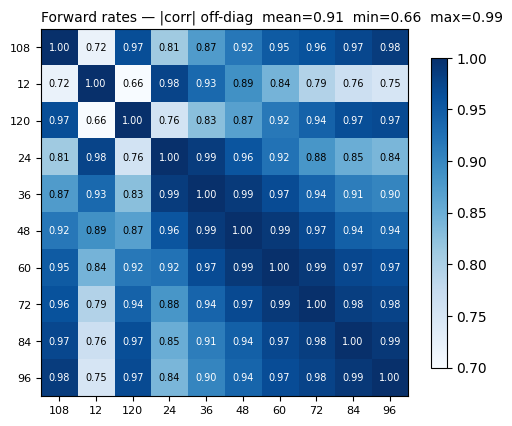

In [29]:
# Correlation heatmap of the 10 raw forward rates across the OOS window.
fwd_oos = X['forward'].loc[X.index >= pd.Timestamp('1990-01-31')].copy()
fwd_oos.columns = fwd_oos.columns.get_level_values(-1).astype(str)
corr = fwd_oos.corr()
off = np.abs(corr.values[np.triu_indices_from(corr, k=1)])

fig, ax = plt.subplots(figsize=(5.2, 4.4))
im = ax.imshow(corr.values, vmin=0.7, vmax=1.0, cmap='Blues')
ax.set_xticks(range(len(corr)))
ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, fontsize=8)
ax.set_yticklabels(corr.index, fontsize=8)
ax.set_title(
    f'Forward rates — |corr| off-diag  mean={off.mean():.2f}  '
    f'min={off.min():.2f}  max={off.max():.2f}',
    fontsize=10, loc='left',
)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center',
                fontsize=7, color='white' if corr.values[i, j] > 0.9 else 'black')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## Loader — pick a model and read the parquets

`MODEL` picks between the two wrappers. Group-Shapley tables are read from `artifacts/group_shap/…` and DeepSHAP from `artifacts/shap/…`. Both exist for both models at matching orchestrator timestamps.

In [30]:
# ── Model selector (the only knob you need to touch) ─────────────────────
MODEL = 'group_ensemble'         # 'macro_forward' | 'group_ensemble'
MATS_PRIMARY = ['24', '120']    # 2Y and 10Y anchors used by every tier
# ─────────────────────────────────────────────────────────────────────────

RUN_NAME = {
    'macro_forward':  'macro_forward_ann_valid_3_5seeds',
    'group_ensemble': 'group_ensemble_ann_valid_fwd3_grp3_5seeds',
}[MODEL]

GROUP_SHAP_ROOT = REPO_ROOT / 'artifacts' / 'group_shap' / RUN_NAME
DEEP_SHAP_ROOT  = REPO_ROOT / 'artifacts' / 'shap' / RUN_NAME

def _latest_ts(root: Path) -> Path:
    if not root.exists():
        raise FileNotFoundError(f'No artefacts under {root}. Run compute first.')
    stamps = sorted(p for p in root.iterdir() if p.is_dir())
    if not stamps:
        raise FileNotFoundError(f'No timestamped runs under {root}')
    return stamps[-1]

gs_dir = _latest_ts(GROUP_SHAP_ROOT)
ds_dir = _latest_ts(DEEP_SHAP_ROOT)

gs_mean   = pd.read_parquet(gs_dir / 'group_shap_mean.parquet')
gs_base   = pd.read_parquet(gs_dir / 'group_base_values.parquet')
gs_per_seed = pd.read_parquet(gs_dir / 'group_shap_per_seed.parquet')
ds_mean   = pd.read_parquet(ds_dir / 'shap_mean.parquet')

for df in (gs_mean, gs_base, gs_per_seed, ds_mean):
    df['date'] = pd.to_datetime(df['date'])
    df['maturity'] = df['maturity'].astype(str)

# ── helpers reused across tiers ─────────────────────────────────────────

def parse_ds_block(feat: str) -> str:
    """Map a DeepSHAP feature label to its group name."""
    parts = feat.split('::')
    if parts[0] == 'forward':
        return 'forward'
    if parts[0] == 'fred' and len(parts) >= 3:
        return parts[1]
    if len(parts) >= 2:
        return parts[0]
    return parts[0]

def parse_ds_display(feat: str) -> str:
    parts = feat.split('::')
    if parts[0] == 'forward':
        return f'fwd {parts[-1]}' if len(parts) > 1 else 'fwd'
    if parts[0] == 'fred' and len(parts) >= 3:
        return parts[2]
    if len(parts) >= 2:
        return parts[1]
    return feat

# Canonical player ordering (forward first, macro groups by total importance).
_macro_order = (
    gs_mean[(gs_mean['group'] != 'forward') & (gs_mean['maturity'].isin(MATS_PRIMARY))]
    .groupby('group')['abs_mean_shap'].sum()
    .sort_values(ascending=False).index.tolist()
)
BLOCK_ORDER = ['forward'] + _macro_order

# Classic blue-first palette: grey for forward, blue-shifted colours for macro groups.
_CLASSIC = ['#1f77b4', '#17becf', '#9467bd', '#2ca02c',
            '#bcbd22', '#ff7f0e', '#d62728', '#7f7f7f',
            '#8c564b', '#c5b0d5']
BLOCK_COLOURS = {'forward': '#3a4a5c'}
for i, g in enumerate(_macro_order):
    BLOCK_COLOURS[g] = _CLASSIC[i % len(_CLASSIC)]

def block_label(b: str) -> str:
    return 'Forward rates' if b == 'forward' else b

print(f'MODEL = {MODEL!r}')
print(f'  group-SHAP dir: {gs_dir.name}  |  rows={len(gs_mean):,}  dates={gs_mean["date"].nunique()}')
print(f'  deep-SHAP  dir: {ds_dir.name}  |  rows={len(ds_mean):,}  features={ds_mean["feature"].nunique()}')
print(f'  maturities available: {sorted(gs_mean["maturity"].unique())}')
print(f'  players (canonical order): {BLOCK_ORDER}')

MODEL = 'group_ensemble'
  group-SHAP dir: 20260422_104101  |  rows=18,144  dates=336
  deep-SHAP  dir: 20260422_104101  |  rows=270,144  features=134
  maturities available: ['120', '24', '36', '48', '60', '84']
  players (canonical order): ['forward', 'Labor Market', 'Housing', 'Interest and Exchange Rates', 'Money and Credit', 'Stock Market', 'Prices', 'Output and Income', 'Consumption, Orders, and Inventories']


## Tier 1 — Composition overview (group Shapley)

For each of 2Y and 10Y we show the **share of total \|SHAP\| attribution** at the group level,

$$\text{share}(g,m) \;=\; \frac{\overline{|\Phi_{g,m}|}}{\sum_{g'}\overline{|\Phi_{g',m}|}}, \qquad \overline{|\Phi_{g,m}|} = \frac{1}{T}\sum_{t=1}^{T}|\Phi_{g,m,t}|,$$

where $\Phi_{g,m,t}$ is the exact group-Shapley value of player $g$ at maturity $m$ and date $t$ (top-$k$-seed ensemble mean). Two panels: a horizontal stacked bar (one row per maturity, fills sum to 100%) and two donut charts annotated with the same shares. The stacked bar is the most compact direct-comparison view; the donuts reproduce the Bianchi-style aesthetic and make the absolute share of each player legible at a glance.

/var/folders/ld/n7jgnqtj56n39lqfp56jr5240000gn/T/ipykernel_16949/2808694092.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


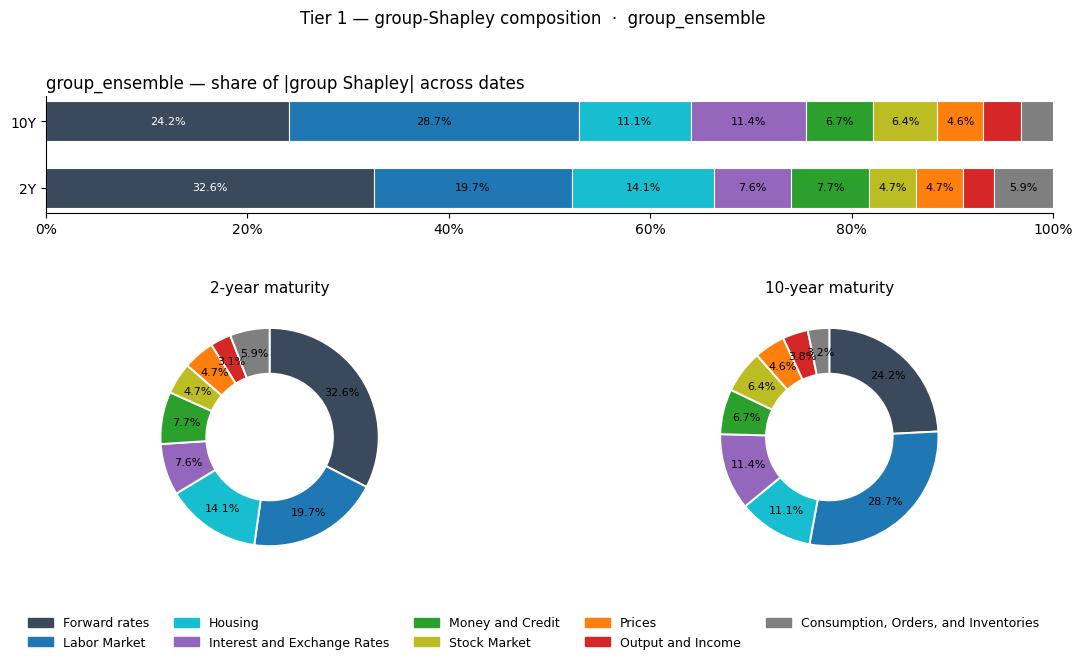


=== group_ensemble · group-Shapley shares (%) ===
                                      10Y_share_%  2Y_share_%
group                                                        
forward                                     24.19       32.57
Labor Market                                28.74       19.69
Housing                                     11.13       14.08
Interest and Exchange Rates                 11.37        7.64
Money and Credit                             6.69        7.74
Stock Market                                 6.36        4.67
Prices                                       4.59        4.66
Output and Income                            3.77        3.08
Consumption, Orders, and Inventories         3.17        5.87


In [31]:
# Tier 1 — group-Shapley composition, 2Y & 10Y
t1 = (
    gs_mean[gs_mean['maturity'].isin(MATS_PRIMARY)]
    .groupby(['maturity', 'group'])['abs_mean_shap']
    .mean()
    .unstack('group')
    .reindex(columns=BLOCK_ORDER)
    .fillna(0.0)
)
shares = t1.div(t1.sum(axis=1), axis=0)

fig = plt.figure(figsize=(13, 6.2))
gs = fig.add_gridspec(2, 2, height_ratios=[0.9, 2.1], hspace=0.45, wspace=0.25)

# -- top: stacked horizontal bar (one row per maturity, normalised to 100%) --
ax_bar = fig.add_subplot(gs[0, :])
for i, mat in enumerate(MATS_PRIMARY):
    left = 0.0
    row = shares.loc[mat]
    for b in BLOCK_ORDER:
        w = float(row[b])
        if w <= 0:
            continue
        ax_bar.barh(i, w, left=left, color=BLOCK_COLOURS[b],
                    edgecolor='white', linewidth=0.8, height=0.6)
        if w >= 0.04:
            ax_bar.text(left + w / 2, i, f'{w*100:.1f}%', ha='center', va='center',
                        fontsize=8,
                        color='white' if b == 'forward' else 'black')
        left += w
ax_bar.set_yticks(range(len(MATS_PRIMARY)))
ax_bar.set_yticklabels([f'{int(m)//12}Y' for m in MATS_PRIMARY])
ax_bar.set_xlim(0, 1)
ax_bar.set_xticks(np.linspace(0, 1, 6))
ax_bar.set_xticklabels([f'{int(v*100)}%' for v in np.linspace(0, 1, 6)])
ax_bar.set_title(f'{MODEL} — share of |group Shapley| across dates', loc='left')
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)

# -- bottom: donut charts, one per maturity --
for j, mat in enumerate(MATS_PRIMARY):
    ax = fig.add_subplot(gs[1, j])
    row = shares.loc[mat].values
    colours = [BLOCK_COLOURS[b] for b in BLOCK_ORDER]
    wedges, _, autotexts = ax.pie(
        row, labels=None, colors=colours,
        startangle=90, counterclock=False,
        wedgeprops=dict(width=0.42, edgecolor='white', linewidth=1.4),
        autopct=lambda p: f'{p:.1f}%' if p >= 3 else '',
        pctdistance=0.78,
    )
    for t in autotexts:
        t.set_fontsize(8)
    ax.set_title(f'{int(mat)//12}-year maturity', fontsize=11)

handles = [plt.Rectangle((0, 0), 1, 1, color=BLOCK_COLOURS[b]) for b in BLOCK_ORDER]
fig.legend(handles, [block_label(b) for b in BLOCK_ORDER],
           loc='lower center', bbox_to_anchor=(0.5, -0.03),
           ncol=min(len(BLOCK_ORDER), 5), frameon=False, fontsize=9)
fig.suptitle(f'Tier 1 — group-Shapley composition  ·  {MODEL}', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# Printable table.
tbl = (shares * 100).round(2).T
tbl.columns = [f'{int(m)//12}Y_share_%' for m in tbl.columns]
print('\n=== ' + str(MODEL) + ' · group-Shapley shares (%) ===')
print(tbl.to_string())

## Tier 2 — Bianchi-style: individual features + group pie

Two panels per maturity (2Y and 10Y, four panels total):
- **Left** — ranked bar of the top individual *macro* features (forwards excluded) using DeepSHAP's per-feature $|$mean$_{\text{seed}}$ SHAP$|$ averaged across dates. This is the one place where group Shapley cannot help, because it collapses a group to one number by construction. The ranking here tells you *which* FRED-MD series move the prediction the most inside each group.
- **Right** — a donut of group-level share using exact group Shapley (the Tier 1 pie, but repeated next to the individual ranking so the "group" and "feature" views can be read together).

Individual-feature shares are normalised to the top-N sum so the two sub-panels are each "share of what's shown" and do not need to agree on absolute magnitudes.

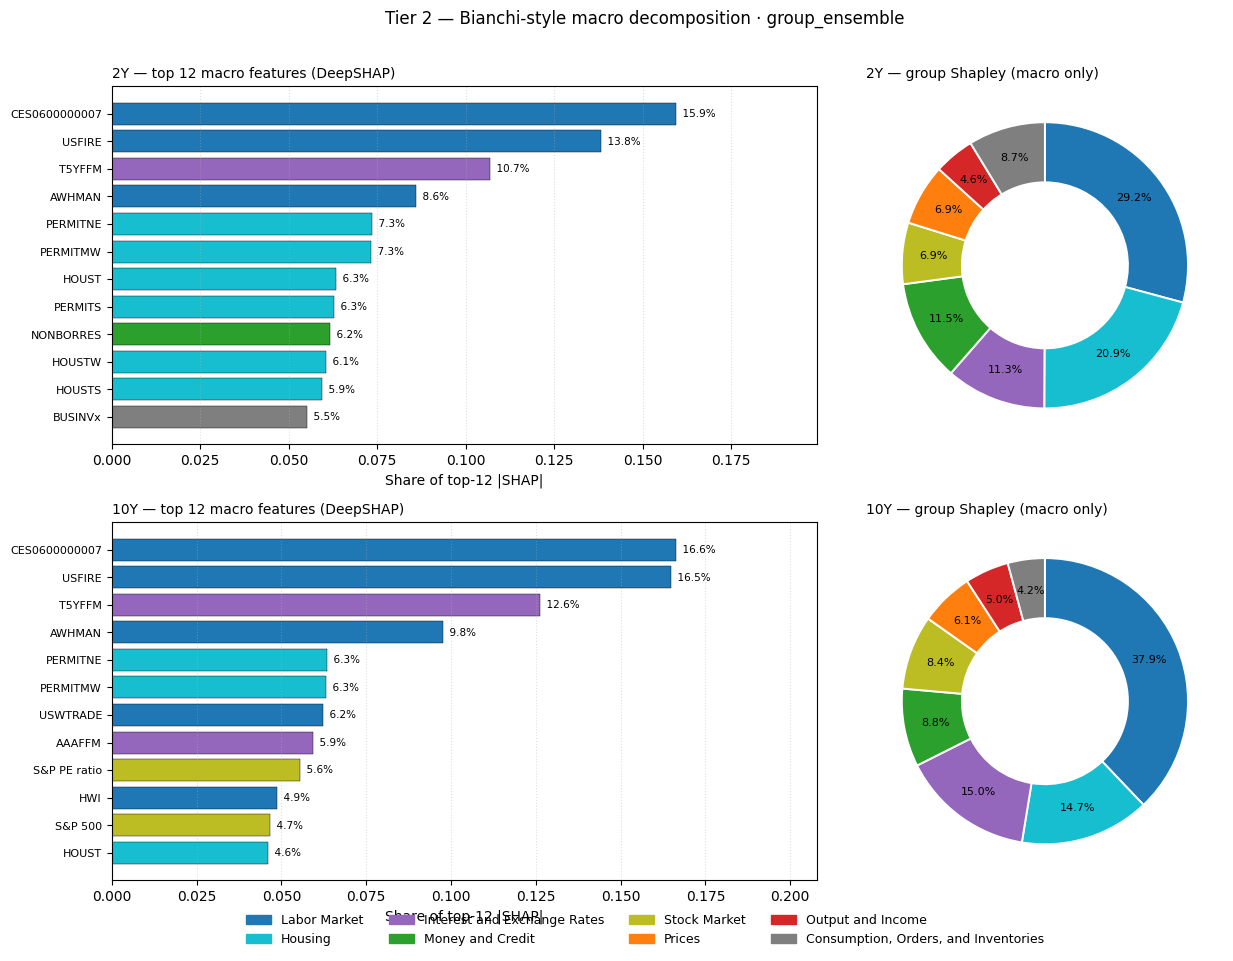

In [32]:
# ── Tier 2 knobs ────────────────────────────────────────────────────────
tier2_top_n = 12
tier2_label_pct_min = 3.0         # hide tiny labels on pie
# ────────────────────────────────────────────────────────────────────────

ds = ds_mean.copy()
ds['block']   = ds['feature'].map(parse_ds_block)
ds['display'] = ds['feature'].map(parse_ds_display)
ds_macro = ds[ds['block'] != 'forward'].copy()

# Feature importance (forwards excluded): mean_t |mean_seed SHAP|.
feat_imp = (
    ds_macro.groupby(['maturity', 'feature', 'block', 'display'])['abs_mean_shap']
    .mean().reset_index(name='importance')
)

fig, axes = plt.subplots(
    len(MATS_PRIMARY), 2,
    figsize=(13, 0.30 * tier2_top_n * len(MATS_PRIMARY) + 2.0),
    gridspec_kw={'width_ratios': [1.5, 1.0]},
    squeeze=False,
)
for i, mat in enumerate(MATS_PRIMARY):
    # -- LEFT: ranked individual macro features (DeepSHAP) ---------------
    ax_l = axes[i, 0]
    sub = feat_imp[feat_imp['maturity'] == mat].nlargest(tier2_top_n, 'importance').copy()
    sub = sub.sort_values('importance', ascending=True)
    rel = sub['importance'] / sub['importance'].sum()
    colours = [BLOCK_COLOURS.get(b, '#999') for b in sub['block']]
    ax_l.barh(sub['display'], rel, color=colours, edgecolor='black', linewidth=0.3)
    for y, v in zip(sub['display'], rel):
        ax_l.text(v, y, f'  {v*100:.1f}%', va='center', fontsize=7.5)
    ax_l.set_xlim(0, rel.max() * 1.25)
    ax_l.set_xlabel('Share of top-{} |SHAP|'.format(tier2_top_n))
    ax_l.set_title(f'{int(mat)//12}Y — top {tier2_top_n} macro features (DeepSHAP)',
                   fontsize=10, loc='left')
    ax_l.tick_params(axis='y', labelsize=8)
    ax_l.grid(axis='x', linestyle=':', alpha=0.4)

    # -- RIGHT: group-Shapley donut, macro groups only -------------------
    ax_r = axes[i, 1]
    row = shares.loc[mat].drop('forward')
    row = row / row.sum()                        # renormalise (forwards excluded)
    colours_pie = [BLOCK_COLOURS[b] for b in row.index]
    wedges, _, autotexts = ax_r.pie(
        row.values, colors=colours_pie, startangle=90, counterclock=False,
        wedgeprops=dict(width=0.42, edgecolor='white', linewidth=1.4),
        autopct=lambda p: f'{p:.1f}%' if p >= tier2_label_pct_min else '',
        pctdistance=0.78,
    )
    for t in autotexts:
        t.set_fontsize(8)
    ax_r.set_title(f'{int(mat)//12}Y — group Shapley (macro only)',
                   fontsize=10, loc='left')

handles = [plt.Rectangle((0, 0), 1, 1, color=BLOCK_COLOURS[b]) for b in _macro_order]
fig.legend(handles, _macro_order, loc='lower center', bbox_to_anchor=(0.5, -0.02),
           ncol=min(len(_macro_order), 4), frameon=False, fontsize=9)
fig.suptitle(f'Tier 2 — Bianchi-style macro decomposition · {MODEL}',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## Tier 3 — Spanning hypothesis: macro vs forwards over time

For each date $t$ and maturity $m$ the macro share is

$$s^\text{macro}_{m,t} \;=\; \frac{\sum_{g \neq \text{fwd}} |\Phi_{g,m,t}|}{\sum_{g} |\Phi_{g,m,t}|},$$

computed from **9-player** exact group Shapley (forward + eight macro groups). Values near 0.5 mean the macro groups and the forward block contribute roughly equally; values above 0.5 mean macro variables drive the prediction more than the forward term structure on that date. We plot a rolling mean at 2Y and 10Y — the spanning hypothesis predicts the macro share should be *small* if forwards span the risk-premium information.

**Tier 3b** (below) plots the same quantity in the **two-player** (forward vs pooled macro) game from `group_shap_binary` artefacts, in the same style as the gross DeepSHAP spanning figure in `shap_analysis.ipynb`.

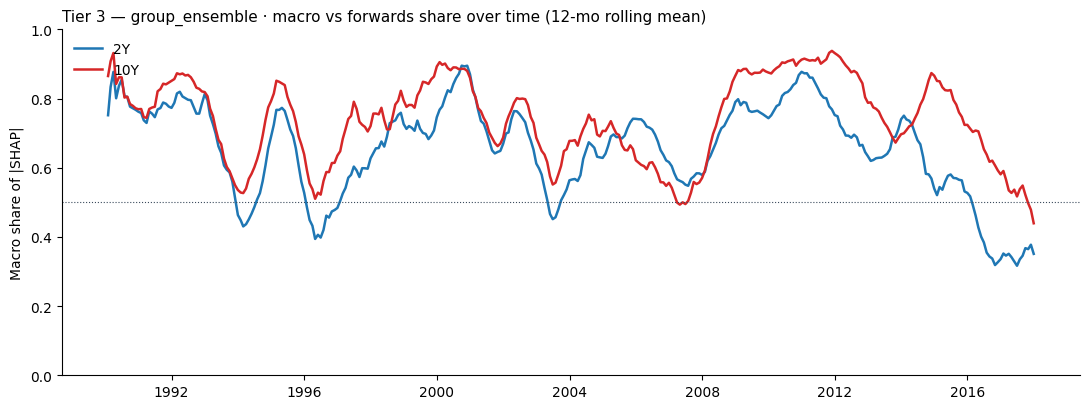


=== group_ensemble · macro share summary ===
      mean    std    min    max
2Y   0.649  0.187  0.155  0.993
10Y  0.732  0.180  0.164  0.996


In [33]:
# ── Tier 3 knobs ────────────────────────────────────────────────────────
tier3_smoothing = 12         # rolling-mean window (months)
# ────────────────────────────────────────────────────────────────────────

def _macro_share_ts(mat: str) -> pd.Series:
    sub = gs_mean[gs_mean['maturity'] == mat].copy()
    sub['block'] = np.where(sub['group'] == 'forward', 'forward', 'macro')
    tot = sub.groupby(['date', 'block'])['abs_mean_shap'].sum().unstack('block').fillna(0.0)
    return (tot['macro'] / (tot['forward'] + tot['macro']).replace(0, np.nan)).sort_index()

ts_share = pd.concat(
    {f'{int(m)//12}Y': _macro_share_ts(m) for m in MATS_PRIMARY}, axis=1,
)
ts_smooth = ts_share.rolling(tier3_smoothing, min_periods=1).mean() if tier3_smoothing > 1 else ts_share

fig, ax = plt.subplots(figsize=(11, 4.2))
for mat, c in zip(MATS_PRIMARY, ['#1f77b4', '#d62728']):
    lbl = f'{int(mat)//12}Y'
    ax.plot(ts_smooth.index, ts_smooth[lbl], color=c, linewidth=1.8, label=lbl)
ax.axhline(0.5, color='#3a4a5c', linestyle=':', linewidth=0.8)
ax.set_ylim(0, 1)
ax.set_ylabel('Macro share of |SHAP|')
ax.set_title(
    f'Tier 3 — {MODEL} · macro vs forwards share over time ({tier3_smoothing}-mo rolling mean)',
    loc='left', fontsize=11,
)
ax.legend(frameon=False, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

desc = ts_share.describe().round(3).T[['mean', 'std', 'min', 'max']]
print('\n=== ' + str(MODEL) + ' · macro share summary ===')
print(desc.to_string())

## Tier 3b — Two-player group Shapley (spanning, 2Y & 10Y)

Exact Shapley in the **forward vs macro** game (`artifacts/group_shap_binary/…`). Uses the **same `MODEL` and `MATS_PRIMARY`** as the loader cell. Requires the binary compute cell above.


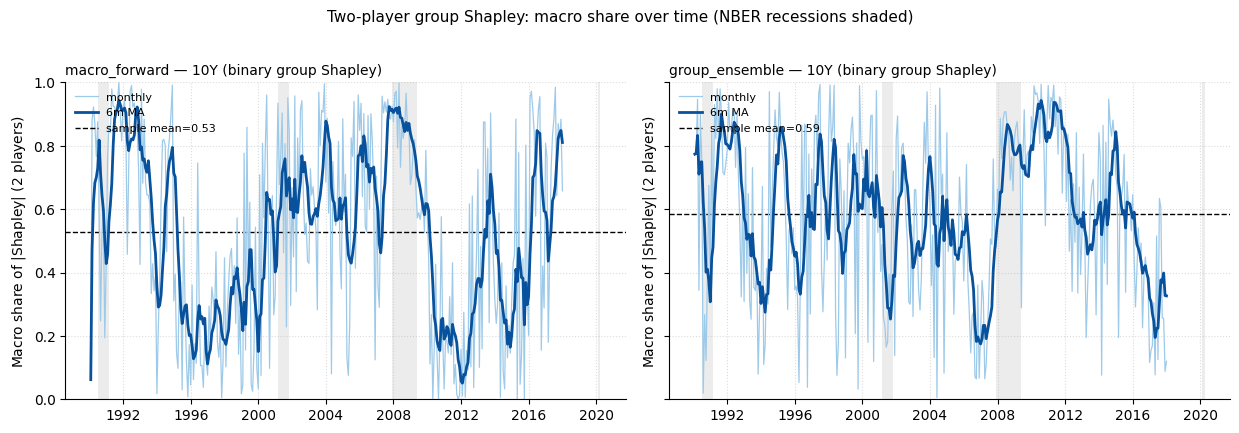


=== Binary group Shapley · 10Y ===
macro_forward count    336.000
mean       0.529
std        0.313
min        0.000
25%        0.241
50%        0.574
75%        0.823
max        0.999
group_ensemble count    336.000
mean       0.586
std        0.266
min        0.006
25%        0.362
50%        0.638
75%        0.811
max        0.994


In [34]:
# ── Tier 3b knobs ───────────────────────────────────────────────────────
tier3b_ma_months = 6        # MA window; match shap_analysis spanning figure
# (maturities: reuse MATS_PRIMARY from the loader cell)
# ───────────────────────────────────────────────────────────────────────

nber_recessions = [
    ('1990-07-01', '1991-03-01'), ('2001-03-01', '2001-11-01'),
    ('2007-12-01', '2009-06-01'), ('2020-02-01', '2020-04-01'),
]
nber_recessions = [(pd.Timestamp(a), pd.Timestamp(b)) for a, b in nber_recessions]


def _shade_recessions_t3b(ax, alpha=0.15, color='0.5'):
    y0, y1 = ax.get_ylim()
    for start, end in nber_recessions:
        ax.axvspan(start, end, facecolor=color, alpha=alpha, linewidth=0, zorder=0)
    ax.set_ylim(y0, y1)


def _latest_bin_dir(run_name: str):
    root = REPO_ROOT / 'artifacts' / 'group_shap_binary' / run_name
    if not root.is_dir():
        return None
    stamps = sorted(p for p in root.iterdir() if p.is_dir())
    return stamps[-1] if stamps else None


def _macro_share_from_binary_parquet(p: Path, mat: str) -> pd.Series:
    gsm = pd.read_parquet(p)
    gsm = gsm[gsm['maturity'].astype(str) == str(mat)].copy()
    gsm['date'] = pd.to_datetime(gsm['date'])
    wide = gsm.pivot_table(
        index='date', columns='group', values='abs_mean_shap', aggfunc='first',
    )
    if 'forward' not in wide.columns or 'macro' not in wide.columns:
        return pd.Series(dtype=float)
    return (
        wide['macro'] / (wide['forward'] + wide['macro']).replace(0, np.nan)
    ).sort_index()


_d_bin = _latest_bin_dir(RUN_NAME)
_p_bin = _d_bin / 'group_shap_mean.parquet' if _d_bin is not None else None

bin_ts_by_mat = {}
if _p_bin is not None and _p_bin.is_file():
    for _mat in MATS_PRIMARY:
        bin_ts_by_mat[_mat] = _macro_share_from_binary_parquet(_p_bin, _mat)

if not bin_ts_by_mat or all(s.empty for s in bin_ts_by_mat.values()):
    print(
        'No `artifacts/group_shap_binary/.../group_shap_mean.parquet`. '
        'Run the 2-player compute cell above.'
    )
else:
    fig_b, axes_b = plt.subplots(
        1, len(MATS_PRIMARY), figsize=(6.3 * len(MATS_PRIMARY), 4.2), sharey=True, squeeze=False,
    )
    ax_list = np.asarray(axes_b, dtype=object).ravel().tolist()
    for ax, mat in zip(ax_list, MATS_PRIMARY):
        lbl = f'{int(mat)//12}Y'
        monthly = bin_ts_by_mat.get(mat, pd.Series(dtype=float)).dropna().sort_index()
        if monthly.empty:
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{MODEL} — {lbl} (binary group Shapley)')
            continue
        ma = monthly.rolling(tier3b_ma_months, min_periods=1).mean()
        mean_v = float(monthly.mean())
        ax.plot(monthly.index, monthly, color='#9ecae9', linewidth=0.9, label='monthly', zorder=2)
        ax.plot(ma.index, ma, color='#08519c', linewidth=2.0, label=f'{tier3b_ma_months}m MA', zorder=3)
        ax.axhline(mean_v, color='black', linestyle='--', linewidth=1.0,
                   label=f'sample mean={mean_v:.2f}', zorder=1)
        _shade_recessions_t3b(ax)
        ax.set_ylim(0, 1)
        ax.set_ylabel(r'Macro share of $|\mathrm{Shapley}|$ (2 players)')
        ax.set_title(f'{MODEL} — {lbl} (binary group Shapley)', loc='left', fontsize=10)
        ax.legend(frameon=False, loc='upper left', fontsize=8)
        ax.grid(True, linestyle=':', alpha=0.45)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    fig_b.suptitle(
        f'Two-player group Shapley: macro share over time — {MODEL} (NBER recessions shaded)',
        y=1.02, fontsize=11,
    )
    fig_b.autofmt_xdate(rotation=0, ha='center')
    fig_b.tight_layout()
    plt.show()

    print('\n=== Binary group Shapley · ' + str(MODEL) + ' ===')
    for mat, s in bin_ts_by_mat.items():
        if not s.empty:
            print(f'{int(mat)//12}Y', s.describe().round(3).to_string())

## Tier 4 — Per-group share over time (2Y & 10Y)

Where Tier 3 collapses everything to one number per date, Tier 4 keeps each of the 9 players as its own series. For each maturity we plot the stacked **share** of $|\Phi_{g,m,t}|$ so the fills at every date sum to 100% — the visual question is *which* player's slice expands or contracts in which regime. Light NBER-style shading is skipped here for clarity; the Tier 3 time axis still tells the recession story.

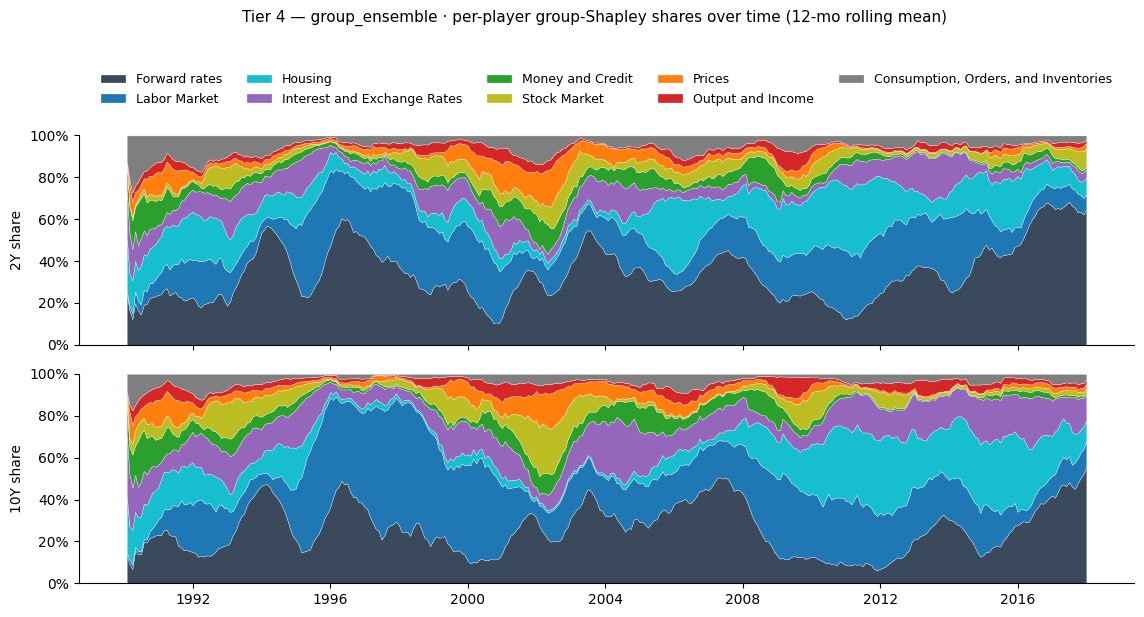

In [35]:
# ── Tier 4 knobs ────────────────────────────────────────────────────────
tier4_smoothing = 12         # same rolling window as Tier 3
# ────────────────────────────────────────────────────────────────────────

def _group_shares_ts(mat: str) -> pd.DataFrame:
    sub = gs_mean[gs_mean['maturity'] == mat]
    wide = (
        sub.pivot_table(index='date', columns='group', values='abs_mean_shap', aggfunc='first')
        .reindex(columns=BLOCK_ORDER)
        .fillna(0.0)
    )
    wide = wide.div(wide.sum(axis=1).replace(0, np.nan), axis=0)
    if tier4_smoothing > 1:
        wide = wide.rolling(tier4_smoothing, min_periods=1).mean()
    return wide.sort_index()

fig, axes = plt.subplots(len(MATS_PRIMARY), 1, figsize=(12, 3.0 * len(MATS_PRIMARY)),
                         sharex=True)
if len(MATS_PRIMARY) == 1:
    axes = [axes]

for ax, mat in zip(axes, MATS_PRIMARY):
    df = _group_shares_ts(mat)
    ax.stackplot(df.index, df[BLOCK_ORDER].T.values,
                 colors=[BLOCK_COLOURS[b] for b in BLOCK_ORDER],
                 labels=[block_label(b) for b in BLOCK_ORDER],
                 edgecolor='white', linewidth=0.2)
    ax.set_ylim(0, 1)
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.set_yticklabels([f'{int(v*100)}%' for v in np.linspace(0, 1, 6)])
    ax.set_ylabel(f'{int(mat)//12}Y share')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.35),
               ncol=min(len(BLOCK_ORDER), 5), frameon=False, fontsize=9)
axes[-1].set_xlabel('')
fig.suptitle(
    f'Tier 4 — {MODEL} · per-player group-Shapley shares over time '
    f'({tier4_smoothing}-mo rolling mean)',
    y=1.02, fontsize=11,
)
plt.tight_layout()
plt.show()

## Tier 5 — Seed stability (group Shapley)

The top-$k$ ensemble averages out idiosyncratic seed noise; this panel quantifies how much noise there was to average. For each player $g$ and maturity $m$ we:

1. Compute per-seed time-averaged attribution $\bar{\Phi}^{(s)}_{g,m} = \frac{1}{T}\sum_t |\Phi^{(s)}_{g,m,t}|$.
2. Convert to a per-seed *share* by dividing by $\sum_{g'}\bar{\Phi}^{(s)}_{g',m}$.
3. Plot the across-seed distribution of that share as a strip plot with the ensemble share as a bold tick.

A narrow strip means the 5 seeds agree on how important each player is; a wide strip flags a player whose importance is seed-sensitive and should be interpreted with caution.

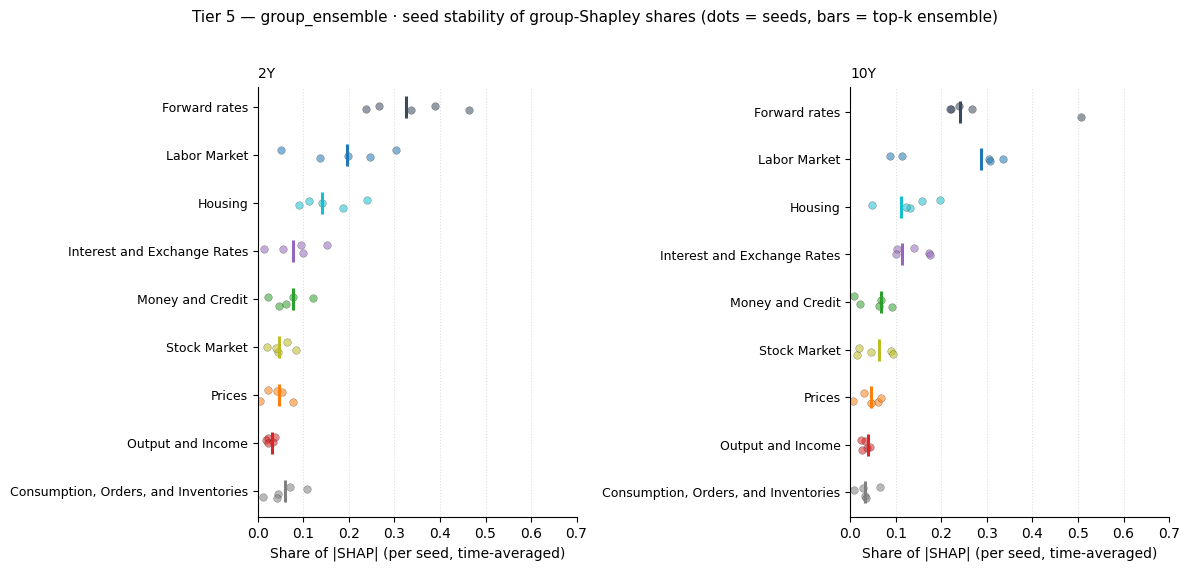


=== group_ensemble · across-seed SD of share (%) ===
          Forward rates  Labor Market  Housing  Interest and Exchange Rates  Money and Credit  Stock Market  Prices  Output and Income  Consumption, Orders, and Inventories
maturity                                                                                                                                                                    
120               10.94         10.60     4.96                         3.24              3.10          3.44    2.16               0.69                                  1.85
24                 8.22          8.77     5.37                         4.64              3.28          2.25    2.45               0.72                                  3.27


In [28]:
# ── Tier 5: per-seed share distribution, one panel per maturity ─────────
per_seed = gs_per_seed[gs_per_seed['maturity'].isin(MATS_PRIMARY)].copy()
per_seed['abs_shap'] = per_seed['shap_value'].abs()

# Step 1 & 2: per-seed share per (maturity, seed, group).
seed_tot = (
    per_seed.groupby(['maturity', 'seed', 'group'])['abs_shap']
    .mean().reset_index()
)
seed_tot['denom'] = seed_tot.groupby(['maturity', 'seed'])['abs_shap'].transform('sum')
seed_tot['share'] = seed_tot['abs_shap'] / seed_tot['denom']

# Ensemble share (time-averaged, then normalised within maturity).
ens = (
    gs_mean[gs_mean['maturity'].isin(MATS_PRIMARY)]
    .groupby(['maturity', 'group'])['abs_mean_shap'].mean().reset_index()
)
ens['denom'] = ens.groupby('maturity')['abs_mean_shap'].transform('sum')
ens['share'] = ens['abs_mean_shap'] / ens['denom']

fig, axes = plt.subplots(1, len(MATS_PRIMARY),
                         figsize=(6.0 * len(MATS_PRIMARY), 0.45 * len(BLOCK_ORDER) + 1.5),
                         sharex=True)
if len(MATS_PRIMARY) == 1:
    axes = [axes]

rng = np.random.default_rng(0)
for ax, mat in zip(axes, MATS_PRIMARY):
    for yi, g in enumerate(BLOCK_ORDER[::-1]):          # largest at top
        seeds_df = seed_tot[(seed_tot['maturity'] == mat) & (seed_tot['group'] == g)]
        if not seeds_df.empty:
            jitter = rng.uniform(-0.14, 0.14, size=len(seeds_df))
            ax.scatter(seeds_df['share'].values, yi + jitter,
                       color=BLOCK_COLOURS[g], alpha=0.55, s=30,
                       edgecolor='black', linewidth=0.25)
        ens_row = ens[(ens['maturity'] == mat) & (ens['group'] == g)]
        if not ens_row.empty:
            ax.scatter(ens_row['share'].values, [yi], color=BLOCK_COLOURS[g],
                       marker='|', s=260, linewidth=2.2)
    ax.set_yticks(range(len(BLOCK_ORDER)))
    ax.set_yticklabels([block_label(b) for b in BLOCK_ORDER[::-1]], fontsize=9)
    ax.set_xlim(0, max(0.7, seed_tot['share'].max() * 1.1))
    ax.set_xlabel('Share of |SHAP| (per seed, time-averaged)')
    ax.set_title(f'{int(mat)//12}Y', fontsize=10, loc='left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', linestyle=':', alpha=0.4)

fig.suptitle(
    f'Tier 5 — {MODEL} · seed stability of group-Shapley shares '
    f'(dots = seeds, bars = top-k ensemble)',
    y=1.02, fontsize=11,
)
plt.tight_layout()
plt.show()

# Compact numeric summary: within-maturity across-seed SD of shares.
sd_tbl = (
    seed_tot.groupby(['maturity', 'group'])['share']
    .std(ddof=0).mul(100).round(2).unstack('group')[BLOCK_ORDER]
)
sd_tbl.columns = [block_label(c) for c in sd_tbl.columns]
print('\n=== ' + str(MODEL) + ' · across-seed SD of share (%) ===')
print(sd_tbl.to_string())